In [2]:
import torch
from src.models.our_method.swin_cafm import SwinCAFM
from src.datasets.mos2_sr import MOS2SRDataset, BTO_MANY_RES, MOS2_SEF_MANY_RES_SRC_DIR, MOS2_SAPPHIRE_DIR
from src.datasets.mos2_sr import BTOSRDataset

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
weights_fp = "/playpen/mufan/levi/tianlong-chen-lab/sparse-cafm/__weights__/4x/DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5_best.pth"
dataset = MOS2SRDataset(src_dir=MOS2_SAPPHIRE_DIR, split="val")
dataset = BTOSRDataset(split="val")
model: SwinCAFM = torch.load(weights_fp).cuda();

/tmp/ipykernel_1741183/363715630.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: SwinCAFM = torch.load(weights_fp).cuda();


In [4]:
X_sparse: torch.Tensor = dataset[0]["X_sparse"].unsqueeze(0).cuda()

In [5]:
with torch.no_grad():
    X_hat: torch.Tensor = model(X_sparse)

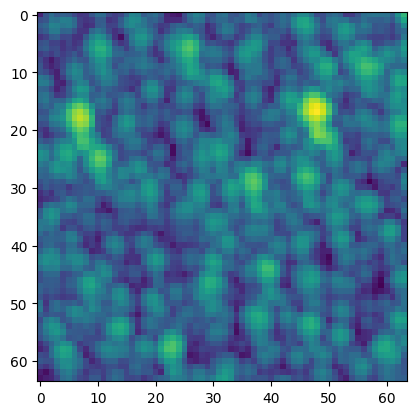

In [6]:
import matplotlib.pyplot as plt

X_hat = X_hat.cpu().squeeze()
X_sparse = X_sparse.cpu().squeeze().numpy()

plt.imshow(X_sparse);

# Plot
---

In [7]:
X_sparse = (X_sparse - dataset.topo_maps_max) / (dataset.topo_maps_max - dataset.topo_maps_min)
X_hat = (X_hat - dataset.topo_maps_max) / (dataset.topo_maps_max - dataset.topo_maps_min)

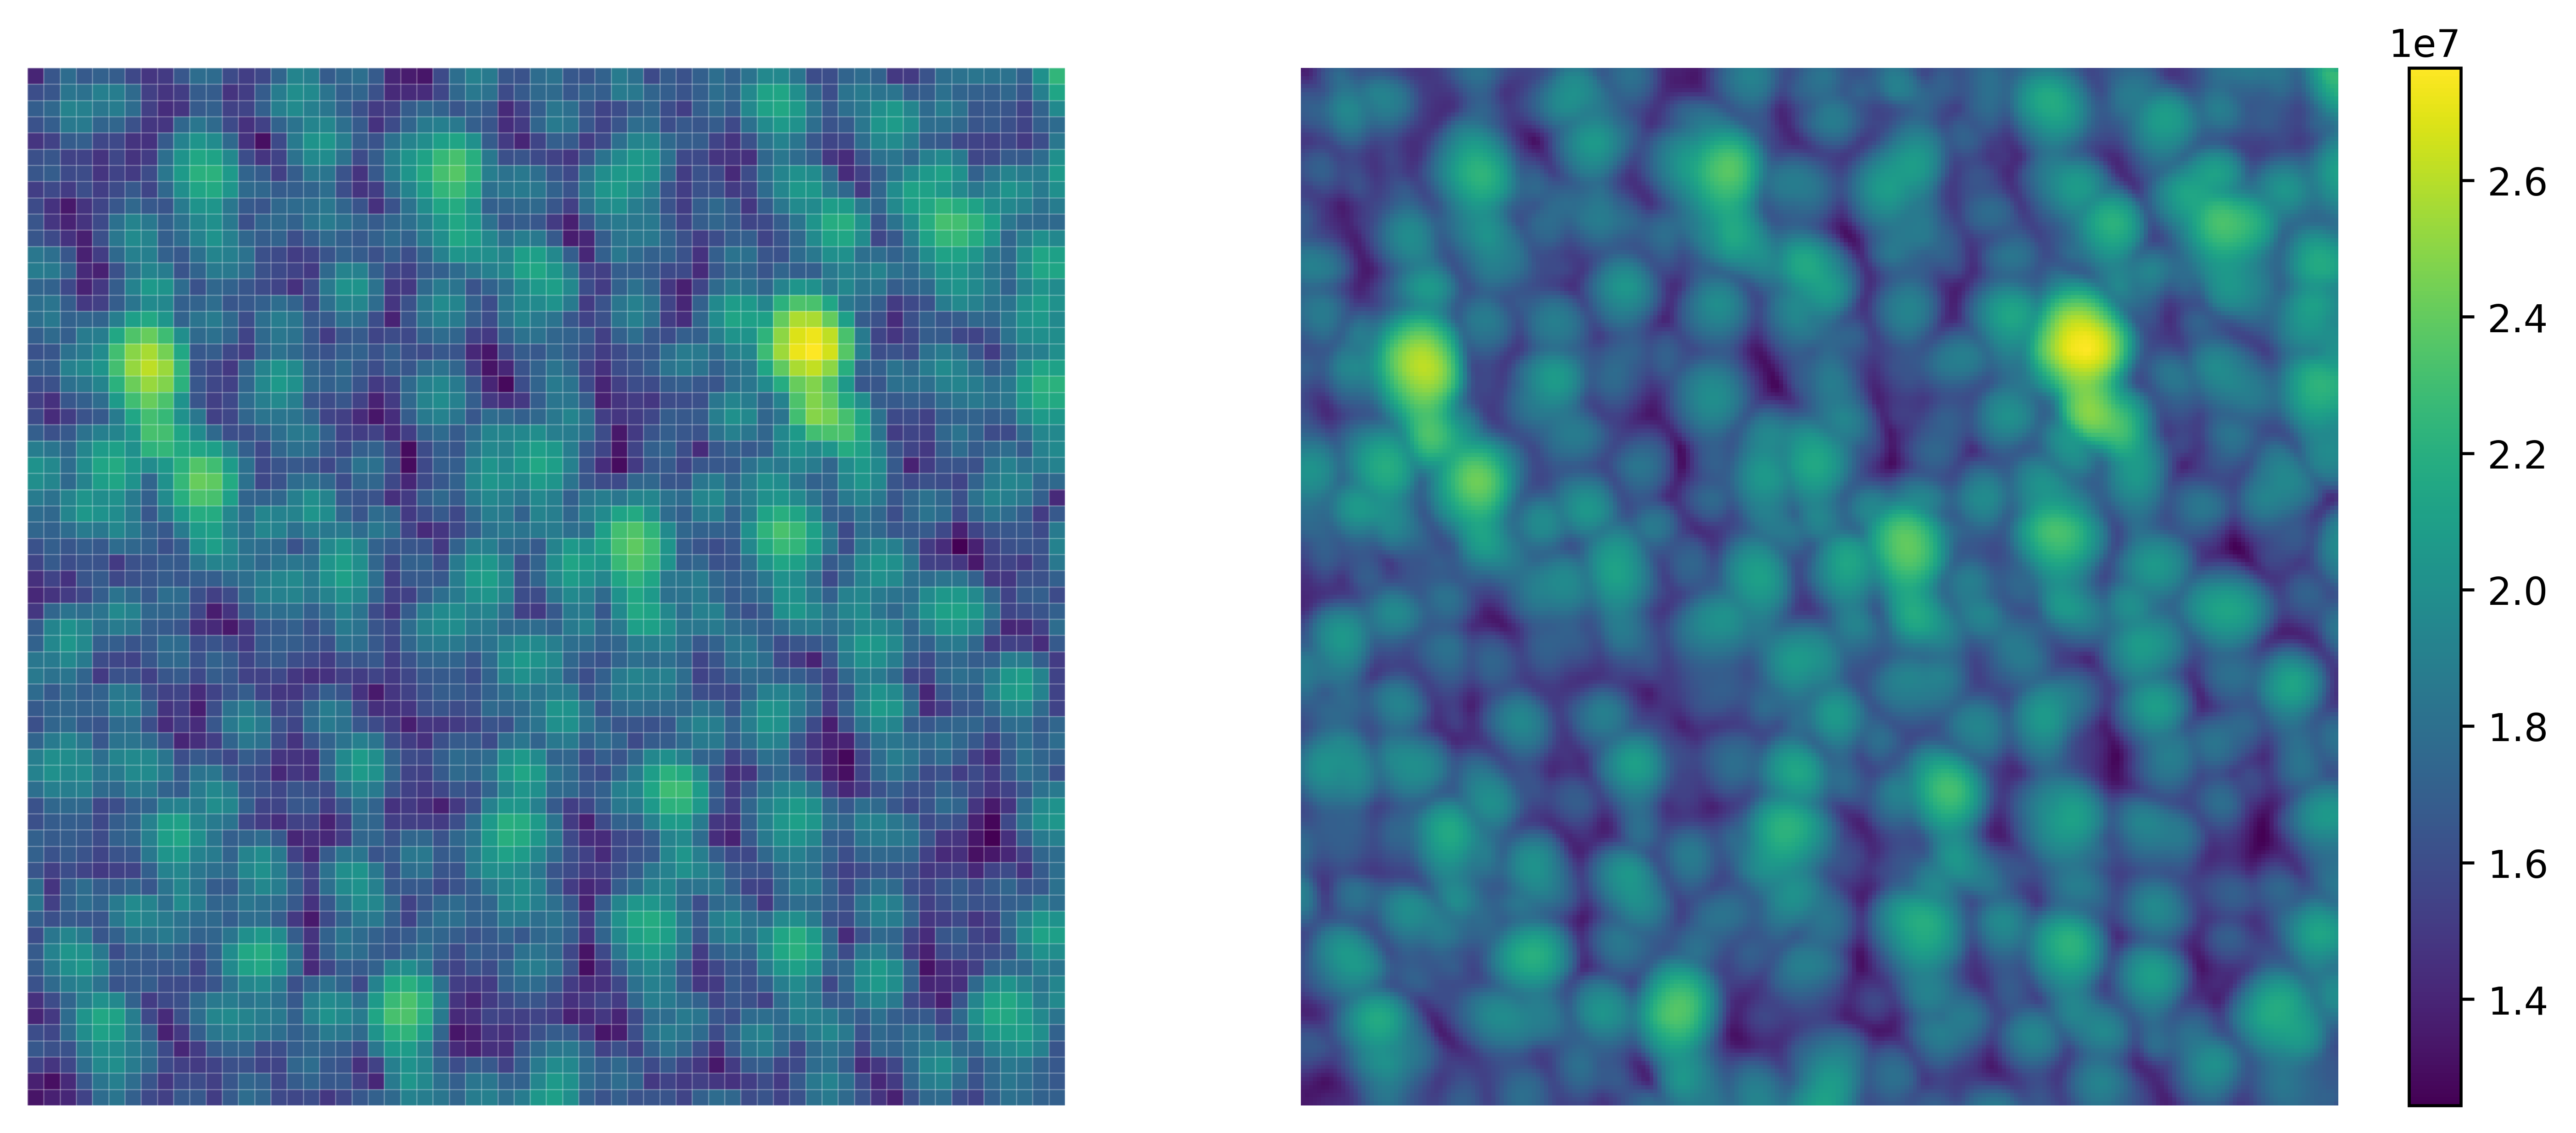

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Xs = X_sparse
Xh = X_hat

# --- 1. Build a masked array: mask pixels that are exactly zero ----------
Xs_masked = np.ma.masked_where(Xs == 0, Xs)

# --- 3. Make the figure --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, dpi=600)

# LEFT: sparse — no interpolation, transparent background for masked cells
im0 = ax[0].imshow(
        Xs_masked,
        cmap="viridis",
        interpolation="nearest",   # keep blocky look
      )
# ax[0].set_title("Input (sparse)")
ax[0].axis("off")

# OPTIONAL: overlay very faint grid lines every pixel
# (comment out if you don’t like the look)
for i in range(Xs.shape[0] + 1):
    ax[0].axhline(i - 0.5, color="w", linewidth=0.3, alpha=0.3)
    ax[0].axvline(i - 0.5, color="w", linewidth=0.3, alpha=0.3)

# RIGHT: dense prediction
im1 = ax[1].imshow(
        Xh,
        cmap="viridis",
      )
# ax[1].set_title("Prediction (dense)")
ax[1].axis("off")

# Colour‑bar shared
fig.colorbar(im1, ax=ax.ravel().tolist(), pad=0.02)

plt.show()